In [1]:
import pathlib
import tqdm

In [2]:
import subprocess, json, textwrap
import numpy as np

def run_idx(idx: int):
    try:
        completed = subprocess.run(
            ["taskset", "-c", "0", "python", "run_one_estimate.py", str(idx)],
            text=True,
            capture_output=True,   # keep both stdout **and** stderr
            check=True,
        )
        return json.loads(completed.stdout)

    except subprocess.CalledProcessError as e:
        print(f"\n--- child process stderr for idx={idx} ---\n")
        print(textwrap.indent(e.stderr, prefix="│ "))
        print("\n-----------------------------------------\n")
        raise                     # re-raise so you still see the notebook error


In [3]:
num_iterations = 1296

In [4]:
# tqdmiter = tqdm.trange(
#     446, num_iterations,
#     desc="Running simulations",
#     unit="iteration",)

File for iteration 225 is corrupted
File for iteration 445 is corrupted
File for iteration 834 is corrupted
File for iteration 1279 is corrupted

In [5]:
tqdmiter = tqdm.trange(1088,
    num_iterations,
    desc="Running simulations",
    unit="iteration",)

for i in tqdmiter:
    out = run_idx(i)
    print(f"Simulation {i+1}/{num_iterations} completed RMSE: {out['rmse']}")
    desc_str = f"Simulation {i+1}/{num_iterations}: "
    tqdmiter.set_description(desc_str)


Simulation 1089/1296: :   0%|          | 1/208 [00:31<1:48:38, 31.49s/iteration]

Simulation 1089/1296 completed RMSE: 0.0035199467092752457


Simulation 1089/1296: :   0%|          | 1/208 [00:40<2:20:59, 40.87s/iteration]


KeyboardInterrupt: 

In [5]:
def load_the_data(idx):
    # Load the data from the results
    data = np.load(f"param_est_files2/run_{idx}.npz", allow_pickle=True)
    diffs_anode = data["diffs_anode"].item()
    diffs_cathode = data["diffs_cathode"].item()
    concentrations_anode = data["concentrations_anode"].item()
    concentrations_cathode = data["concentrations_cathode"].item()
    voltages = data["voltages"].item()
    convergence_metrics = data["convergence_metrics"].item()

    return diffs_anode, diffs_cathode, concentrations_anode, concentrations_cathode, voltages, convergence_metrics

In [6]:
diffs_anode = {
    "log10_Dan_cape_fno": [],
    "log10_Dan_pybamm": [],
    "log10_Dan_true": []
}

diffs_cathode = {
    "log10_Dca_cape_fno": [],
    "log10_Dca_pybamm": [],
    "log10_Dca_true": []
}

concentrations_anode = {
    "c_an_pybamm_from_cape_fno": [],
    "c_an_data": [],
    "c_an_pybamm_from_pybamm": [],
    "c_an_cape_fno_from_cape_fno": [],
    "c_an_cape_fno_from_pybamm": [],
}

concentrations_cathode = {
    "c_ca_pybamm_from_cape_fno": [],
    "c_ca_data": [],
    "c_ca_pybamm_from_pybamm": [],
    "c_ca_cape_fno_from_cape_fno": [],
    "c_ca_cape_fno_from_pybamm": [],
}

voltages = {
    "V_best_cape_fno_from_cape_fno": [],
    "V_best_cape_fno_from_pybamm": [],
    "V_best_pybamm_from_cape_fno": [],
    "V_best_pybamm_from_pybamm": [],
    "V_data": [],
}

convergence_metrics = {
    "res_capefno": [],
    "res_pybamm": [],
}

In [7]:
def single_data_append(diffs_anode_idx, diffs_cathode_idx, concentrations_anode_idx, concentrations_cathode_idx, voltages_idx, convergence_metrics_idx):
    diffs_anode["log10_Dan_cape_fno"].append(diffs_anode_idx["log10_Dan_cape_fno"])
    diffs_anode["log10_Dan_pybamm"].append(diffs_anode_idx["log10_Dan_pybamm"])
    diffs_anode["log10_Dan_true"].append(diffs_anode_idx["log10_Dan_true"])

    diffs_cathode["log10_Dca_cape_fno"].append(diffs_cathode_idx["log10_Dca_cape_fno"])
    diffs_cathode["log10_Dca_pybamm"].append(diffs_cathode_idx["log10_Dca_pybamm"])
    diffs_cathode["log10_Dca_true"].append(diffs_cathode_idx["log10_Dca_true"])

    concentrations_anode["c_an_pybamm_from_cape_fno"].append(concentrations_anode_idx["c_an_pybamm_from_cape_fno"])
    concentrations_anode["c_an_data"].append(concentrations_anode_idx["c_an_data"])
    concentrations_anode["c_an_pybamm_from_pybamm"].append(concentrations_anode_idx["c_an_pybamm_from_pybamm"])
    concentrations_anode["c_an_cape_fno_from_cape_fno"].append(concentrations_anode_idx["c_an_cape_fno_from_cape_fno"])
    concentrations_anode["c_an_cape_fno_from_pybamm"].append(concentrations_anode_idx["c_an_cape_fno_from_pybamm"])

    concentrations_cathode["c_ca_pybamm_from_cape_fno"].append(concentrations_cathode_idx["c_ca_pybamm_from_cape_fno"])
    concentrations_cathode["c_ca_data"].append(concentrations_cathode_idx["c_ca_data"])
    concentrations_cathode["c_ca_pybamm_from_pybamm"].append(concentrations_cathode_idx["c_ca_pybamm_from_pybamm"])
    concentrations_cathode["c_ca_cape_fno_from_cape_fno"].append(concentrations_cathode_idx["c_ca_cape_fno_from_cape_fno"])
    concentrations_cathode["c_ca_cape_fno_from_pybamm"].append(concentrations_cathode_idx["c_ca_cape_fno_from_pybamm"])

    voltages["V_best_cape_fno_from_cape_fno"].append(voltages_idx["V_best_cape_fno_from_cape_fno"])
    voltages["V_best_cape_fno_from_pybamm"].append(voltages_idx["V_best_cape_fno_from_pybamm"])
    voltages["V_best_pybamm_from_cape_fno"].append(voltages_idx["V_best_pybamm_from_cape_fno"])
    voltages["V_best_pybamm_from_pybamm"].append(voltages_idx["V_best_pybamm_from_pybamm"])
    voltages["V_data"].append(voltages_idx["V_data"])

    convergence_metrics["res_capefno"].append(convergence_metrics_idx["res_cape_fno"])
    convergence_metrics["res_pybamm"].append(convergence_metrics_idx["res_pybamm"])

In [8]:
def save_as_npz(out_path: str | pathlib.Path,
                diffs_anode: dict[str, list],
                diffs_cathode: dict[str, list],
                concentrations_anode: dict[str, list],
                concentrations_cathode: dict[str, list],
                voltages: dict[str, list],
                convergence_metrics: dict[str, list]) -> None:
    """
    Flatten the five dictionaries into one `.npz`.
    Each key becomes `<group>/<subkey>` so there are no collisions.
    Lists are turned into object-dtype arrays so differing shapes are OK.
    """
    payload = {}

    def _add_group(prefix: str, group: dict[str, list]):
        for k, v in group.items():
            payload[f"{prefix}/{k}"] = np.asarray(v, dtype=object)

    _add_group("diffs_anode",           diffs_anode)
    _add_group("diffs_cathode",         diffs_cathode)
    _add_group("concentrations_anode",  concentrations_anode)
    _add_group("concentrations_cathode",concentrations_cathode)
    _add_group("voltages",              voltages)
    _add_group("convergence_metrics",   convergence_metrics)

    np.savez_compressed(out_path, **payload)
    print(f"✓ wrote {out_path}")

In [9]:
for i in range(num_iterations):
    
    try:
        diffs_anode_idx, diffs_cathode_idx, concentrations_anode_idx, concentrations_cathode_idx, voltages_idx, convergence_metrics_idx  = load_the_data(i)
    except:
        print(f"File for iteration {i} is corrupted")
        continue

    single_data_append(
        diffs_anode_idx, diffs_cathode_idx, concentrations_anode_idx, concentrations_cathode_idx, voltages_idx, convergence_metrics_idx)

File for iteration 1089 is corrupted
File for iteration 1090 is corrupted
File for iteration 1091 is corrupted
File for iteration 1092 is corrupted
File for iteration 1093 is corrupted
File for iteration 1094 is corrupted
File for iteration 1095 is corrupted
File for iteration 1096 is corrupted
File for iteration 1097 is corrupted
File for iteration 1098 is corrupted
File for iteration 1099 is corrupted
File for iteration 1100 is corrupted
File for iteration 1101 is corrupted
File for iteration 1102 is corrupted
File for iteration 1103 is corrupted
File for iteration 1104 is corrupted
File for iteration 1105 is corrupted
File for iteration 1106 is corrupted
File for iteration 1107 is corrupted
File for iteration 1108 is corrupted
File for iteration 1109 is corrupted
File for iteration 1110 is corrupted
File for iteration 1111 is corrupted
File for iteration 1112 is corrupted
File for iteration 1113 is corrupted
File for iteration 1114 is corrupted
File for iteration 1115 is corrupted
F

In [10]:
len(diffs_anode["log10_Dan_cape_fno"])

1089

In [11]:
save_as_npz("src/inference/param_est_results2.npz",
            diffs_anode, diffs_cathode,
            concentrations_anode, concentrations_cathode,
            voltages, convergence_metrics)

✓ wrote src/inference/param_est_results2.npz


In [12]:
def load_the_dataset(filename):
    data = np.load(filename, allow_pickle=True)

    # Rebuild the nested dict you started with
    diffs_anode_loaded = {k.split("/",1)[1]: data[k].tolist()
                        for k in data if k.startswith("diffs_anode/")}
    diffs_cathode_loaded = {k.split("/",1)[1]: data[k].tolist()
                            for k in data if k.startswith("diffs_cathode/")}
    concentrations_anode_loaded = {k.split("/",1)[1]: data[k].tolist()
                                for k in data if k.startswith("concentrations_anode/")}
    concentrations_cathode_loaded = {k.split("/",1)[1]: data[k].tolist()
                                    for k in data if k.startswith("concentrations_cathode/")}
    voltages_loaded = {k.split("/",1)[1]: data[k].tolist()
                    for k in data if k.startswith("voltages/")}
    convergence_metrics_loaded = {k.split("/",1)[1]: data[k].tolist()
                    for k in data if k.startswith("convergence_metrics/")}
    
    return diffs_anode_loaded, diffs_cathode_loaded, concentrations_anode_loaded, concentrations_cathode_loaded, voltages_loaded, convergence_metrics_loaded


In [13]:
diffs_anode_loaded, diffs_cathode_loaded, concentrations_anode_loaded, concentrations_cathode_loaded, voltages_loaded, convergence_metrics_loaded = load_the_dataset("src/inference/param_est_results2.npz")

In [14]:
V_preds_cfno = np.array(voltages['V_best_cape_fno_from_cape_fno'])
V_preds_pybamm = np.array(voltages['V_best_pybamm_from_pybamm'])
V_data = np.array(voltages['V_data'])

In [15]:
np.sqrt(np.mean((V_preds_cfno - V_data)**2)) * 1e3

np.float32(7.579991)

In [16]:
np.sqrt(np.mean((V_preds_pybamm - V_data)**2)) * 1e3

np.float32(2.3869588)

In [27]:
res_capefno = np.array(convergence_metrics['res_capefno']) * 1e2
res_pybamm = np.array(convergence_metrics['res_pybamm']) * 1e2

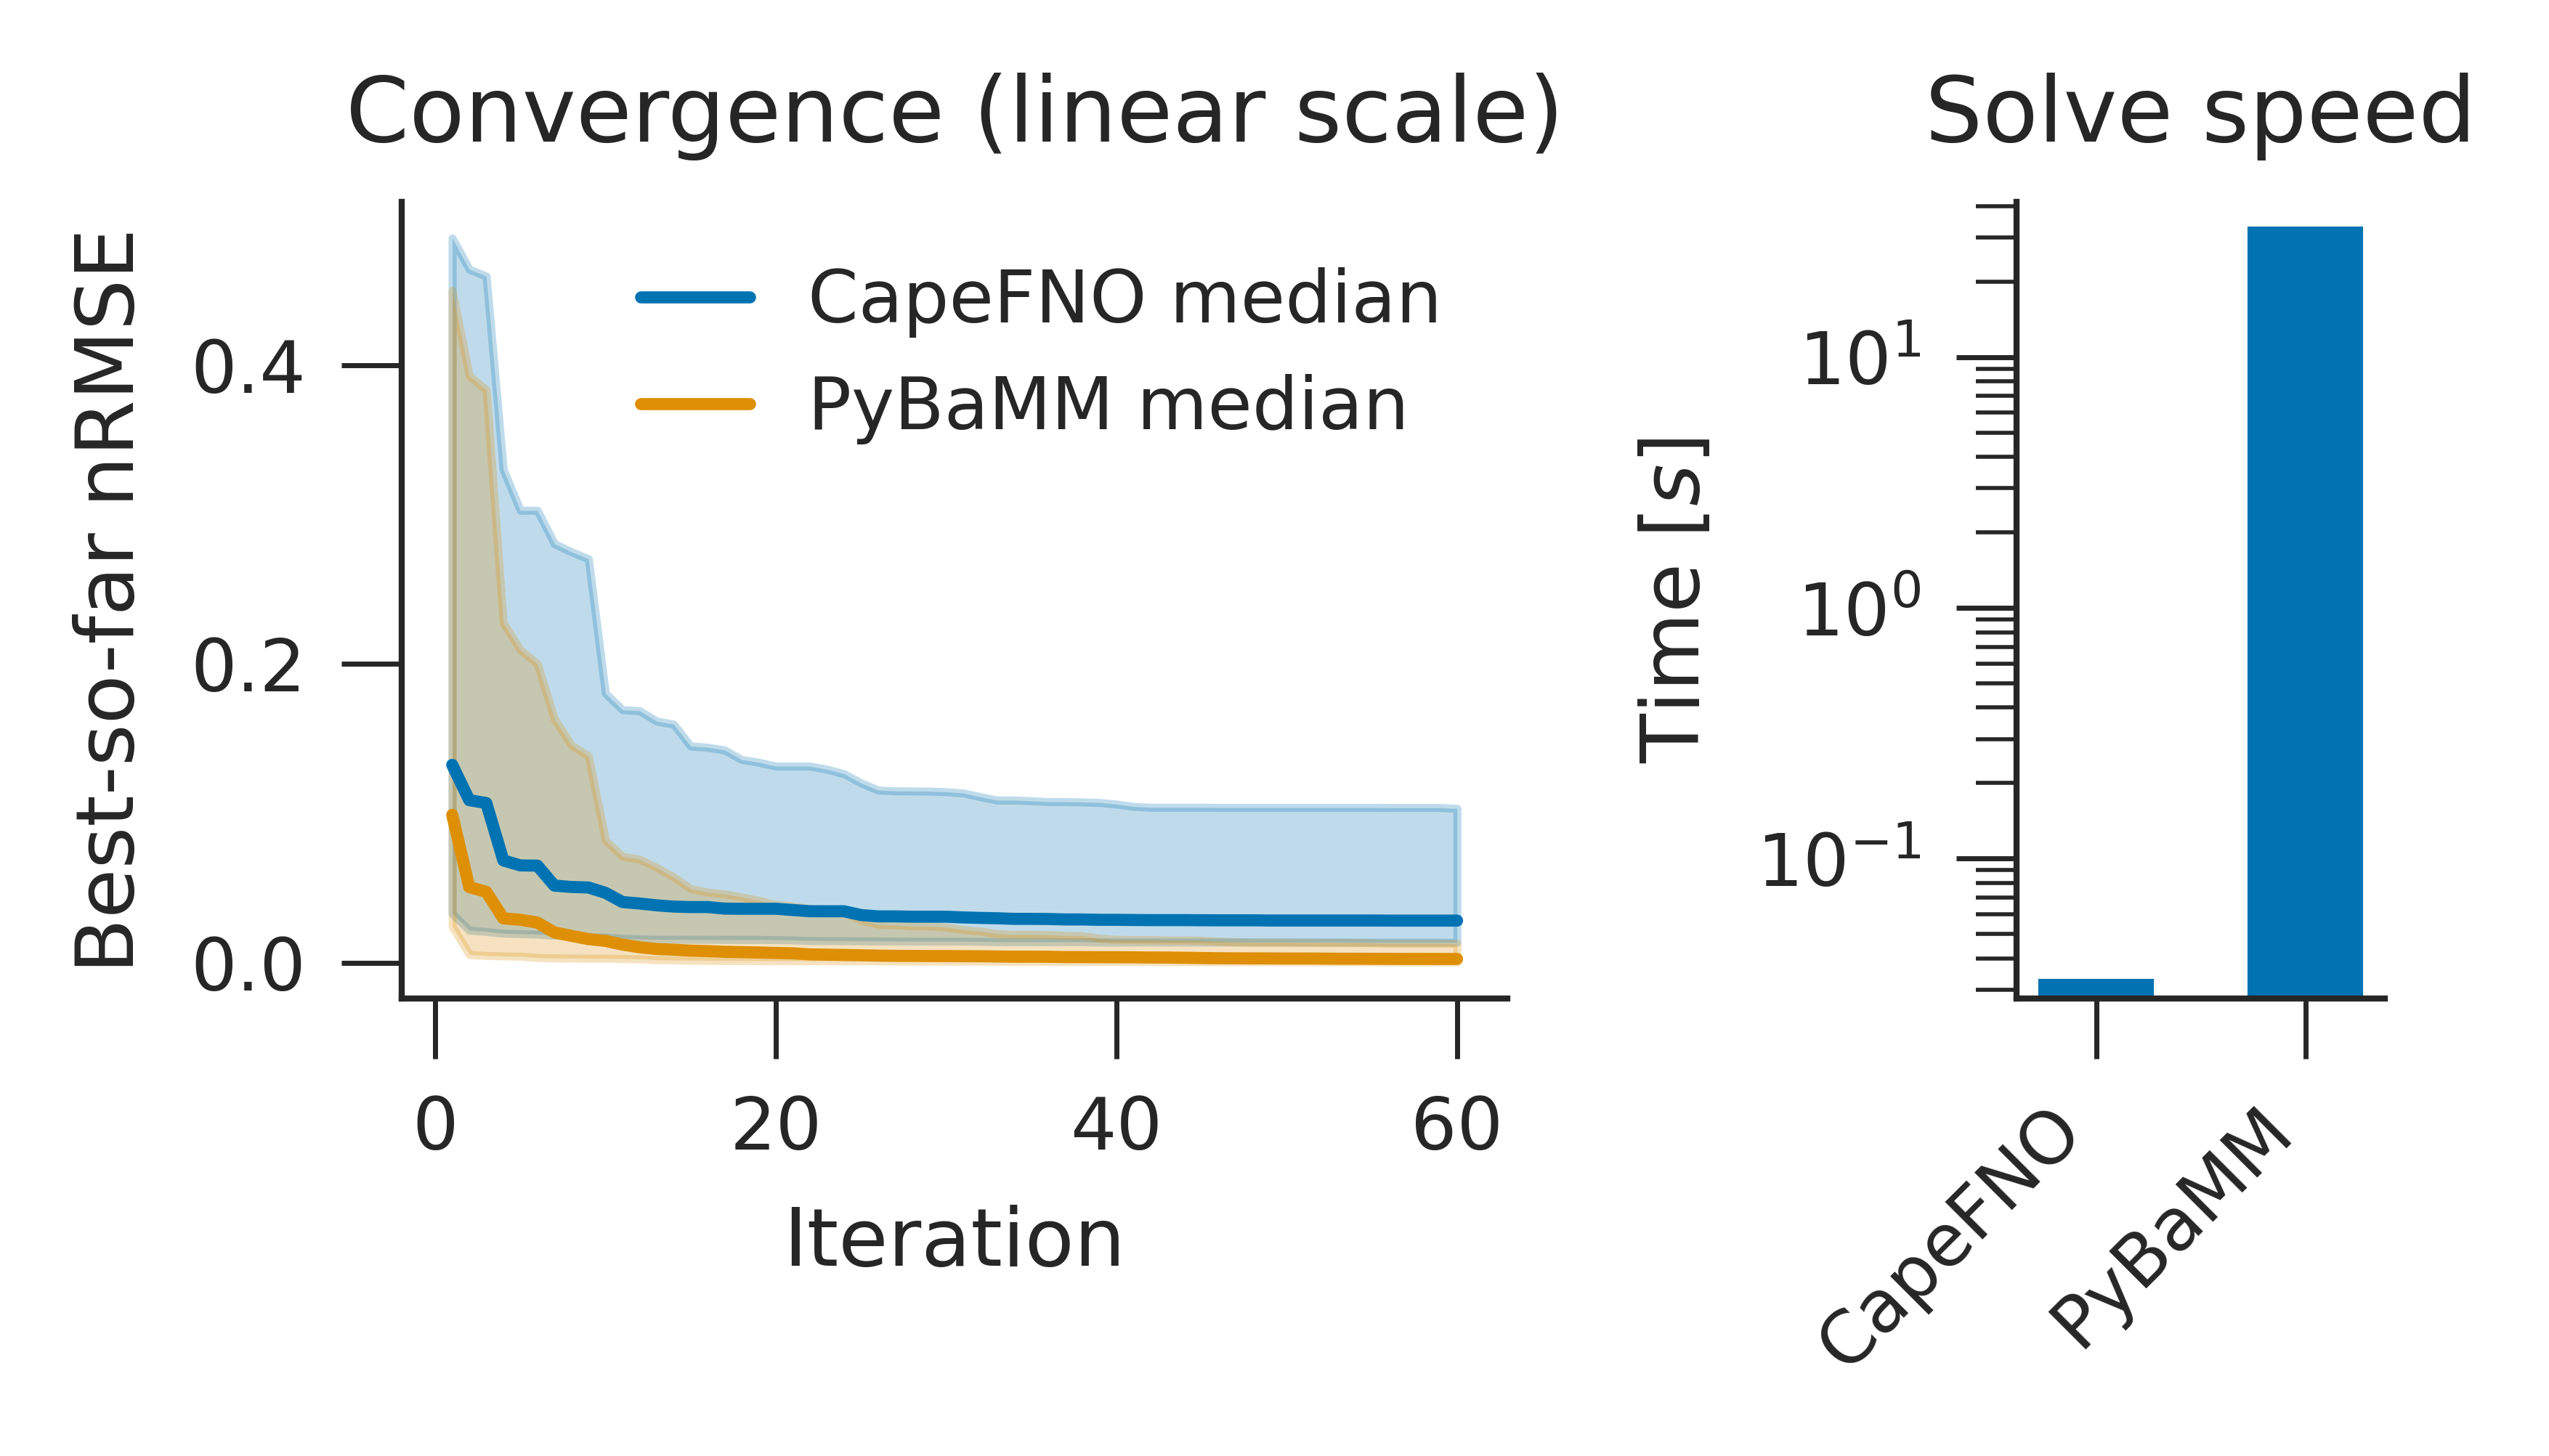

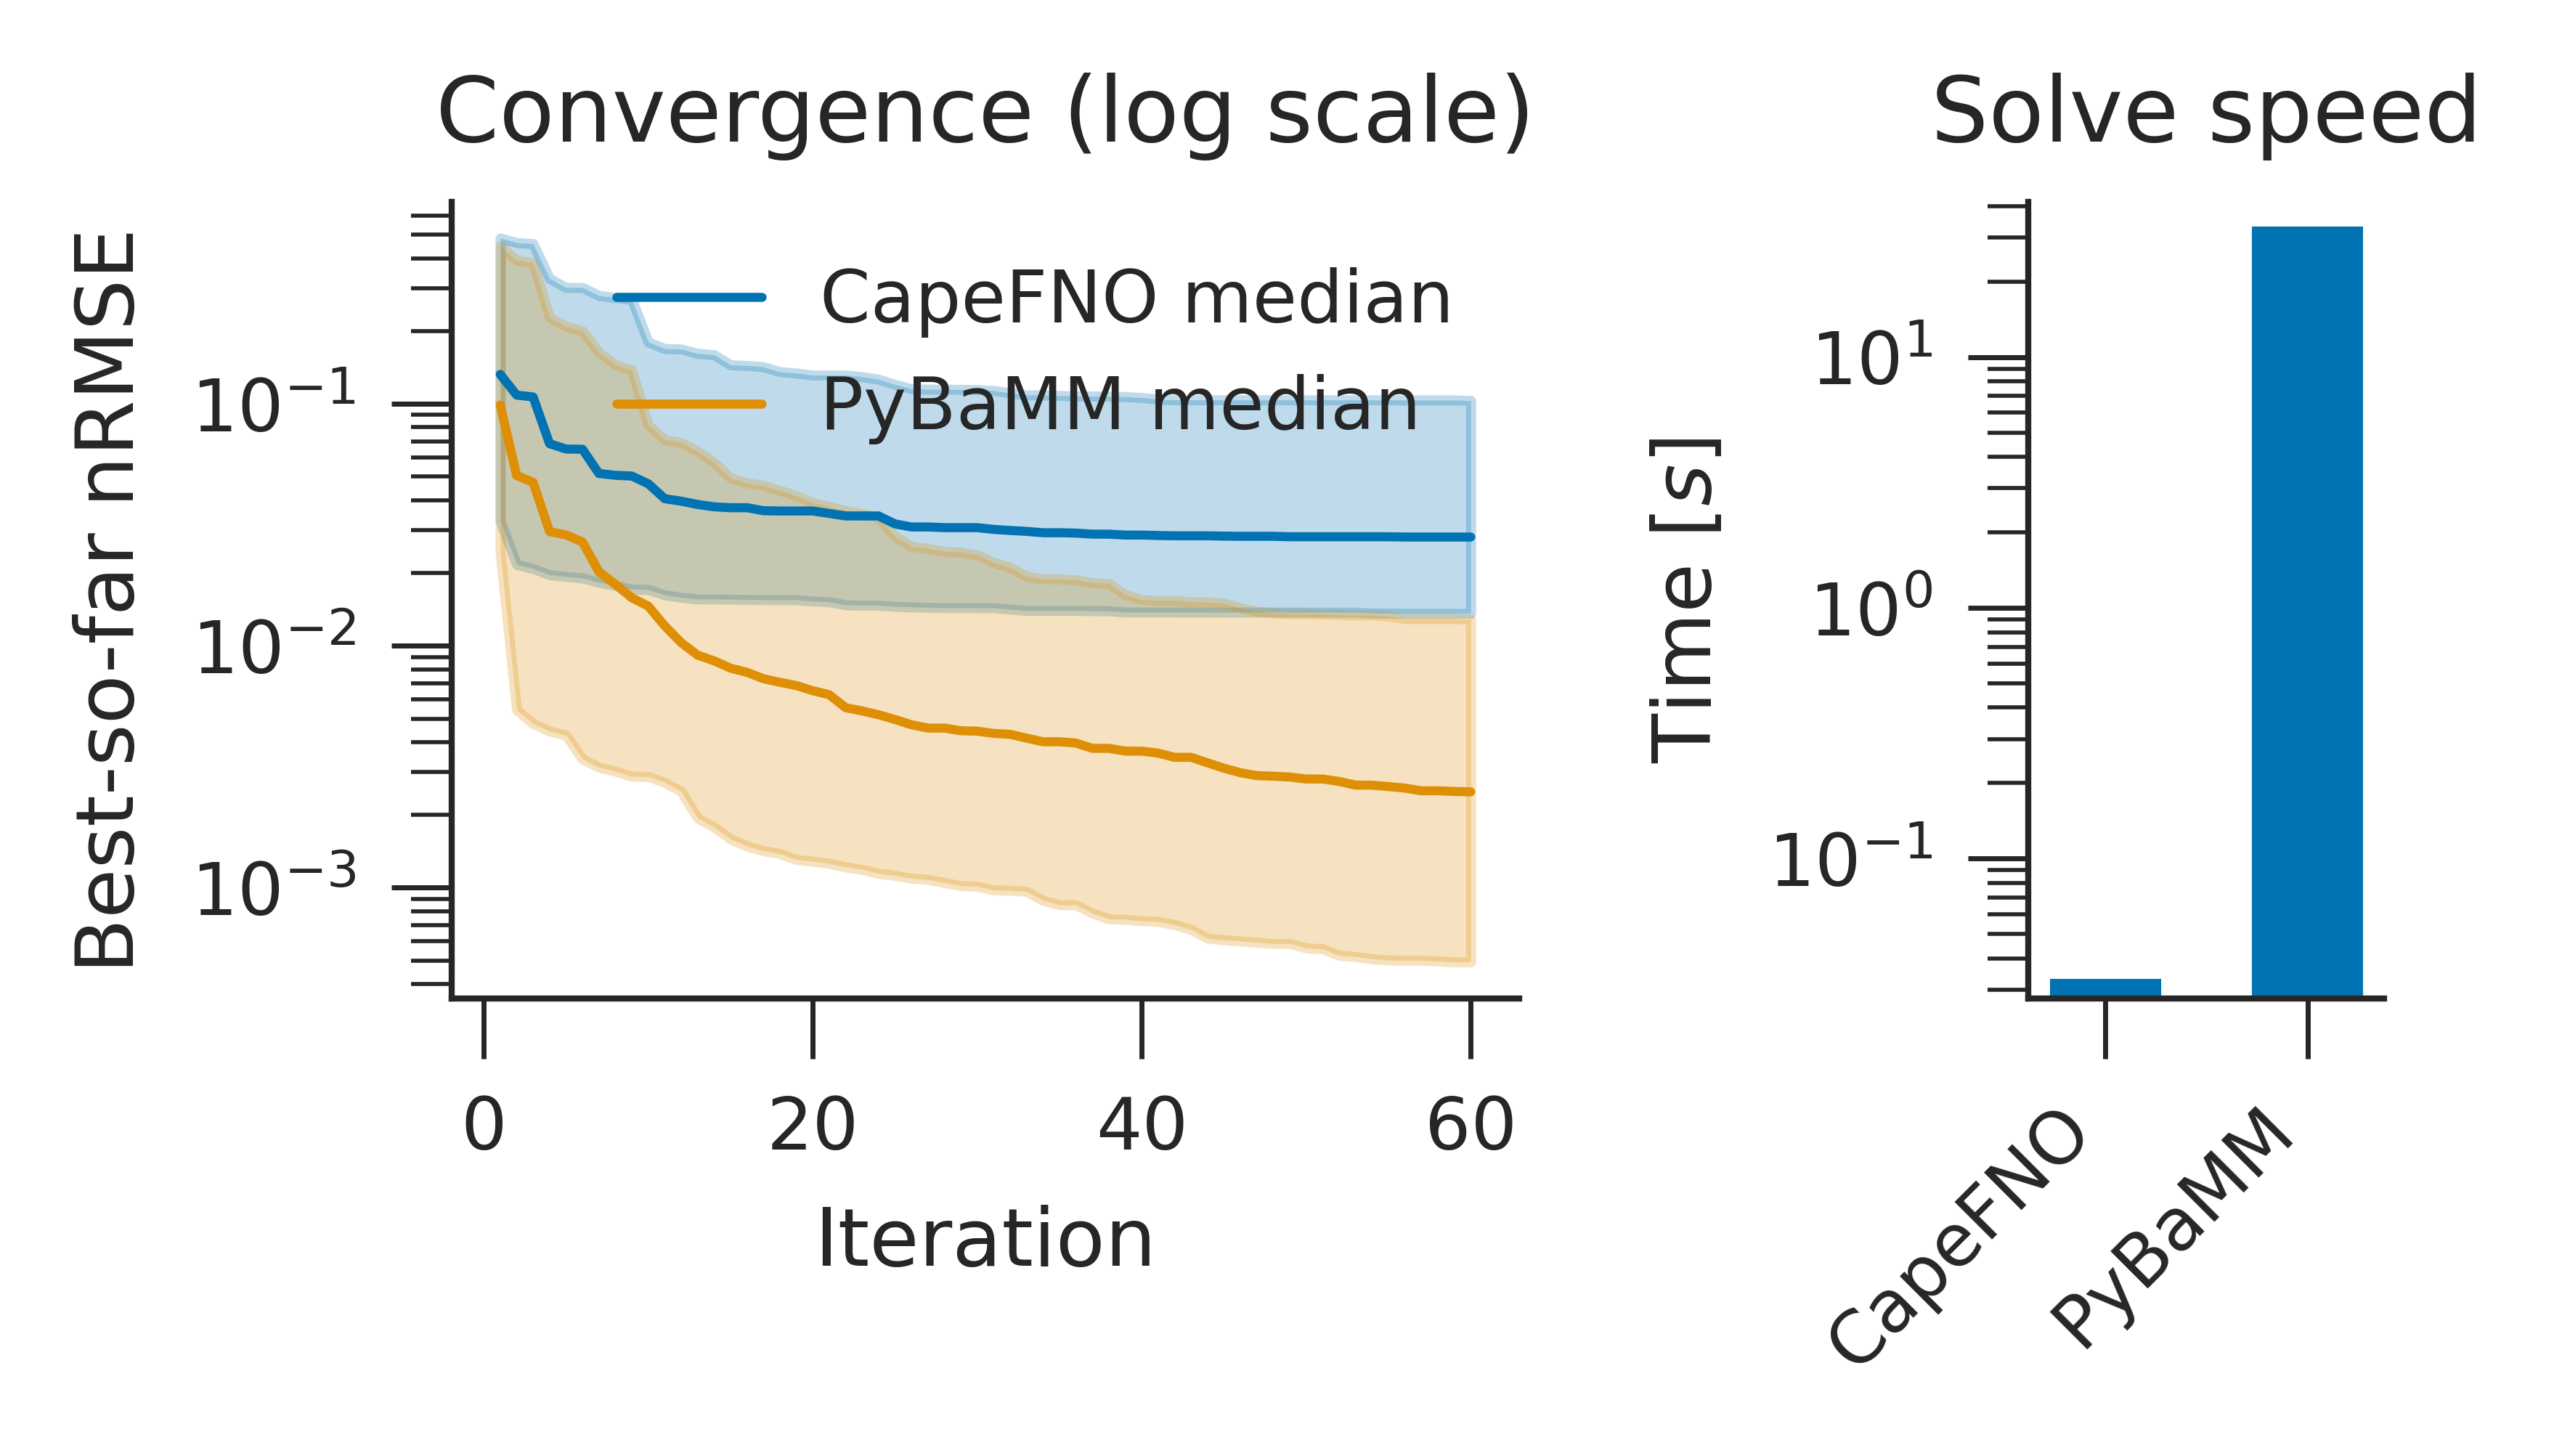

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── DATA (your arrays) ──────────────────────────────────────────────────────
# res_capefno and res_pybamm : shape (1089, 60)

# ── FONT + STROKE PRESETS ───────────────────────────────────────────────────
FS_TITLE, FS_AXLABEL, FS_TICK = 9, 8, 7.2
LW_LINE   = 1.2          # main curves
LW_BAND   = 0.8          # (optional) border of the fill_between ribbon



sns.set_theme(style="ticks")
plt.rcParams.update({
    "axes.titlesize":   FS_TITLE,
    "axes.labelsize":   FS_AXLABEL,
    "xtick.labelsize":  FS_TICK,
    "ytick.labelsize":  FS_TICK,
    "legend.fontsize":  FS_TICK,
    "lines.linewidth":  LW_LINE, 
          # ─── make the frame & ticks slimmer ─────────────────
    "axes.linewidth":        0.6,   # thickness of the four spines
    "xtick.major.width":     0.5,   # major-tick length line
    "ytick.major.width":     0.5,
    "xtick.minor.width":     0.4,
    "ytick.minor.width":     0.4,  # default for everything that follows
})

# ── COLOURS ─────────────────────────────────────────────────────────────────
n_pred = 2
colors = sns.color_palette("colorblind", n_pred)
sns.set_palette(colors)           # makes the colours global

# ── HELPERS ────────────────────────────────────────────────────────────────
def cummin(a):                    # running minimum per chain
    return np.minimum.accumulate(a, axis=1)

def summary_stats(a, lo=25, hi=75):
    median = np.median(a, axis=0)
    p_lo   = np.percentile(a, lo, axis=0)
    p_hi   = np.percentile(a, hi, axis=0)
    return median, p_lo, p_hi

# ── PREP DATA ──────────────────────────────────────────────────────────────
cap_cum = cummin(res_capefno)
pyb_cum = cummin(res_pybamm)

med_cap, p25_cap, p75_cap = summary_stats(cap_cum)
med_pyb, p25_pyb, p75_pyb = summary_stats(pyb_cum)
iters = np.arange(1, cap_cum.shape[1] + 1)

# speed benchmarks (edit freely)
speed = {"CapeFNO": 34.7/1000, "PyBaMM": 34.7}
methods = list(speed)
times   = [speed[m] for m in methods]
x_pos   = np.arange(len(methods))             # 0, 1, …

# ── FIGURE SIZE (one-column, 90 mm) ────────────────────────────────────────
fig_w_mm, fig_h_mm = 90, 55
figsize = (fig_w_mm/25.4, fig_h_mm/25.4)      # mm → inches

fig, (ax_line, ax_bar) = plt.subplots(
    ncols=2, figsize=figsize, dpi=1000,
    gridspec_kw={"width_ratios": [3, 1]},
)

# ── CONVERGENCE CURVES ─────────────────────────────────────────────────────
ax_line.plot(iters, med_cap, label="CapeFNO median")
ax_line.fill_between(
    iters, p25_cap, p75_cap,
    alpha=0.25, linewidth=LW_BAND, edgecolor=colors[0],
)

ax_line.plot(iters, med_pyb, label="PyBaMM median")
ax_line.fill_between(
    iters, p25_pyb, p75_pyb,
    alpha=0.25, linewidth=LW_BAND, edgecolor=colors[1],
)

ax_line.set_xlabel("Iteration")
ax_line.set_ylabel("Best-so-far nRMSE")
ax_line.set_title("Convergence (linear scale)")
ax_line.legend(frameon=False, handlelength=1.5)

# ── VERTICAL “PILLAR” BAR CHART ────────────────────────────────────────────
ax_bar.bar(x_pos, times, width=0.6)

# category labels on the x-axis
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(methods, rotation=45, ha="right", fontsize=FS_TICK)

# ‼ NEW: log-scale for the *y*-axis
ax_bar.set_yscale("log")                       # ← logarithmic

# put a little head- and foot-room so the bars don’t touch the frame
ax_bar.set_ylim(min(times)*0.8, max(times)*1.2)

ax_bar.set_ylabel("Time [$s$]")
ax_bar.set_title("Solve speed", fontsize=FS_TITLE)
sns.despine(ax=ax_bar, left=False)

sns.despine(ax=ax_line)

fig.tight_layout()
fig.savefig("cape_fno_pybamm_convergence.svg", bbox_inches="tight",dpi = 1000)


# ══════════════════════ 2) LOG SCALE ════════════════════════════════════════
fig, (ax_line, ax_bar) = plt.subplots(
    ncols=2, figsize=figsize, dpi=1000,
    gridspec_kw={"width_ratios": [3, 1]},
)

ax_line.plot(iters, med_cap, color=colors[0], lw=0.9, label="CapeFNO median")
ax_line.fill_between(iters, p25_cap, p75_cap, color=colors[0], alpha=0.25)
ax_line.plot(iters, med_pyb, color=colors[1], lw=0.9, label="PyBaMM median")
ax_line.fill_between(iters, p25_pyb, p75_pyb, color=colors[1], alpha=0.25)

ax_line.set_xlabel("Iteration")
ax_line.set_ylabel("Best-so-far nRMSE")
ax_line.set_yscale("log")
ax_line.set_title("Convergence (log scale)")
ax_line.legend(frameon=False)
ax_line.tick_params(labelsize=FS_TICK)

ax_bar.bar(x_pos, times, width=0.6)

# category labels on the x-axis
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(methods, rotation=45, ha="right", fontsize=FS_TICK)

# ‼ NEW: log-scale for the *y*-axis
ax_bar.set_yscale("log")                       # ← logarithmic

# put a little head- and foot-room so the bars don’t touch the frame
ax_bar.set_ylim(min(times)*0.8, max(times)*1.2)

ax_bar.set_ylabel("Time [$s$]")
ax_bar.set_title("Solve speed", fontsize=FS_TITLE)
sns.despine(ax=ax_bar, left=False)

sns.despine(ax=ax_line)
fig.tight_layout()
fig.savefig("cape_fno_pybamm_log.svg", bbox_inches="tight",dpi = 1000)


plt.tight_layout()
plt.show()

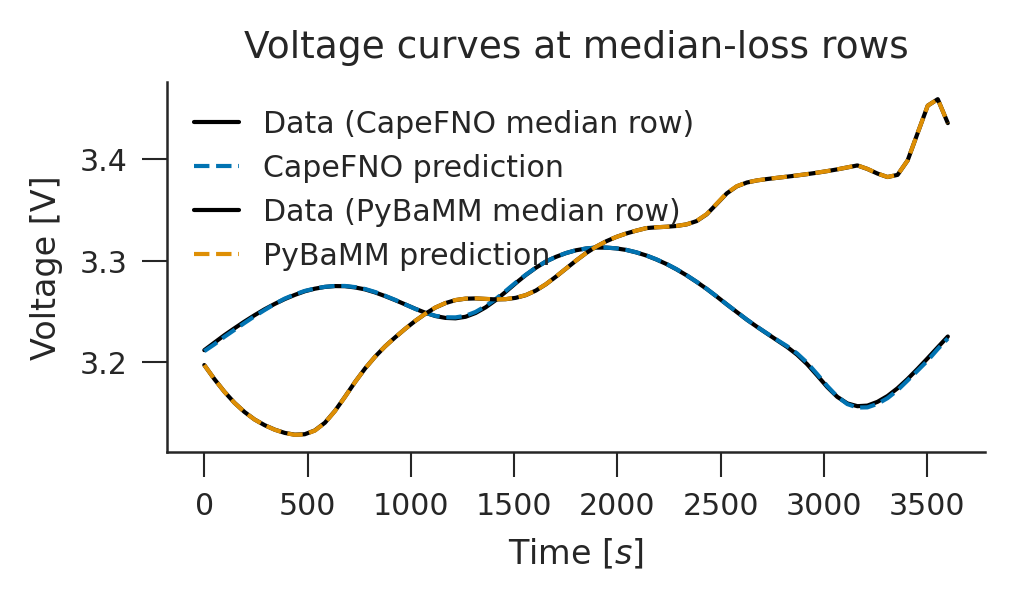

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── prerequisites ───────────────────────────────────────────────────────────
# • res_capefno_cum & res_pybamm_cum  – your running-min arrays (1089×60)
# • V_data, V_preds_cfno, V_preds_pybamm – (1089×75) voltage traces
# ▸  Font & stroke presets, colours, and rcParams block from earlier remain in force.

# ── helper: locate the “median row” (closest final loss) ────────────────────
def median_row_idx(running_min):
    final_vals  = running_min[:, -1]
    med_final   = np.median(final_vals)
    return np.abs(final_vals - med_final).argmin()

idx_cap = median_row_idx(cap_cum)     # running-min array you already built
idx_pyb = median_row_idx(pyb_cum)

# ── grab the voltage curves ────────────────────────────────────────────────
v_data_cap = V_data[idx_cap]          # ground truth for CapeFNO’s median row
v_pred_cap = V_preds_cfno[idx_cap]

v_data_pyb = V_data[idx_pyb]          # ground truth for PyBaMM’s median row
v_pred_pyb = V_preds_pybamm[idx_pyb]

steps = np.linspace(0, 3600, V_data.shape[1])   # 1 … 75

# ── figure size: 90 mm column width ────────────────────────────────────────
fig_w_mm, fig_h_mm = 90, 55
figsize = (fig_w_mm/25.4, fig_h_mm/25.4)

fig, ax = plt.subplots(figsize=figsize, dpi=300)

# colourblind-safe palette already set earlier; reuse it
ax.plot(steps, v_data_cap,  color="0",      lw=1, ls="-",
        label="Data (CapeFNO median row)")
ax.plot(steps, v_pred_cap, color=colors[0],   lw=1, ls= "--",
        label="CapeFNO prediction")

ax.plot(steps, v_data_pyb, color="0",       lw=1, ls="-",
        label="Data (PyBaMM median row)")
ax.plot(steps, v_pred_pyb, color=colors[1],   lw=1, ls= "--",
        label="PyBaMM prediction")

ax.set_xlabel("Time [$s$]")
ax.set_ylabel("Voltage [V]")
ax.set_title("Voltage curves at median-loss rows")
ax.legend(frameon=False, handlelength=1.5, fontsize=FS_TICK)

sns.despine(ax=ax)

fig.tight_layout()
fig.savefig("bayesian_medians.svg", bbox_inches="tight",dpi = 1000)

plt.tight_layout()
plt.show()

